In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

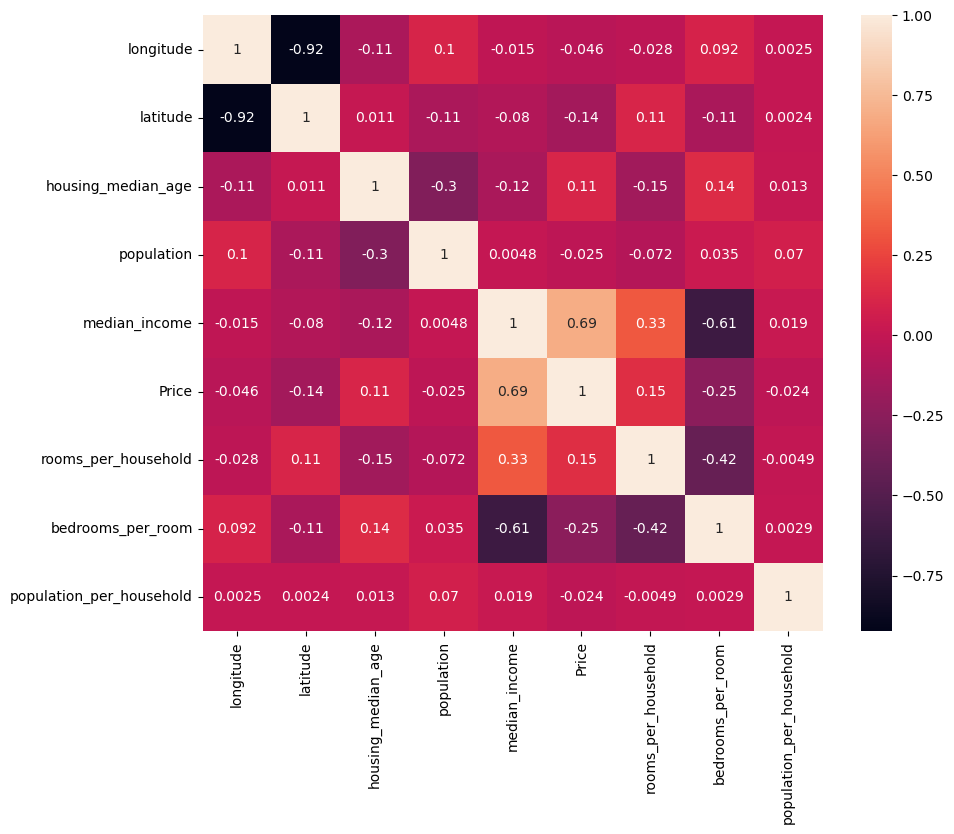

longitude                   0
latitude                    0
housing_median_age          0
population                  0
median_income               0
Price                       0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

In [127]:
df=pd.read_csv("housing.csv")
df=df.drop("ocean_proximity",axis=1)

df.rename(columns={"median_house_value":"Price"},inplace=True)
df.head()

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df = df.drop(["total_rooms", "total_bedrooms", "households"], axis=1)
df["bedrooms_per_room"] = df["bedrooms_per_room"].fillna(df["bedrooms_per_room"].mean())
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()
df.isnull().sum()

In [128]:

X=df.drop("Price",axis=1)
y=df["Price"]
y = y / 100000

In [129]:
X.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
median_income               0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

In [130]:
X.head()

,longitude,latitude,housing_median_age,population,median_income,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,322.0,8.3252,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,2401.0,8.3014,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,496.0,7.2574,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,558.0,5.6431,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,565.0,3.8462,6.281853,0.172096,2.181467


In [131]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [132]:
X_train

,longitude,latitude,housing_median_age,population,median_income,rooms_per_household,bedrooms_per_room,population_per_household
14196,-117.03,32.71,33.0,2300.0,3.2596,5.017657,0.200576,3.691814
8267,-118.16,33.77,49.0,1314.0,3.8125,4.473545,0.232703,1.738095
17445,-120.48,34.66,4.0,915.0,4.1563,5.645833,0.174486,2.723214
14265,-117.11,32.69,36.0,1418.0,1.9425,4.002817,0.258269,3.994366
2271,-119.80,36.78,43.0,874.0,3.5542,6.268421,0.180940,2.300000
...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,658.0,6.3700,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,1753.0,3.0500,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,1756.0,2.9344,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,1777.0,5.7192,6.395349,0.166993,3.178891


In [133]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [134]:
import torch
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [135]:
from torch.utils.data import TensorDataset , DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [141]:
import torch.nn as nn
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [142]:
criterion=nn.MSELoss()
import torch.optim as optim
model=ANN()
optimizer=optim.Adam(model.parameters(),lr=0.0005)

In [143]:
epochs = 150
train_loss=[]
validation_loss=[]
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    train_epoch_loss=0.0
    
    for xb,yb in train_loader:
        
        optimizer.zero_grad()
        outputs=model(xb)
        loss=criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        
        train_epoch_loss+=loss.item()
    average_train_loss=train_epoch_loss/len(train_loader)
    train_loss.append(average_train_loss)
    
    val_epoch_loss=0.0
    model.eval()
    with torch.no_grad():
        for xb,yb in test_loader:
            
            outputs=model(xb)
            loss=criterion(outputs,yb)
            val_epoch_loss+=loss.item()
            
        average_val_loss=val_epoch_loss/len(test_loader)
        validation_loss.append(average_val_loss)
            
    print(f"Epoch {epoch+1}/{epochs} => Train Loss = {average_train_loss:.4f} | Val Loss = {average_val_loss:.4f}")
    if average_val_loss < best_val_loss:
        best_val_loss=average_val_loss
        torch.save(model.state_dict(),"best_practice_model")

Epoch 1/150 => Train Loss = 1.1781 | Val Loss = 0.5105
Epoch 2/150 => Train Loss = 0.4438 | Val Loss = 0.4346
Epoch 3/150 => Train Loss = 0.3973 | Val Loss = 0.3930
Epoch 4/150 => Train Loss = 0.3732 | Val Loss = 0.3698
Epoch 5/150 => Train Loss = 0.3604 | Val Loss = 0.3586
Epoch 6/150 => Train Loss = 0.3462 | Val Loss = 0.3520
Epoch 7/150 => Train Loss = 0.3371 | Val Loss = 0.3415
Epoch 8/150 => Train Loss = 0.3258 | Val Loss = 0.3393
Epoch 9/150 => Train Loss = 0.3305 | Val Loss = 0.3286
Epoch 10/150 => Train Loss = 0.3132 | Val Loss = 0.3272
Epoch 11/150 => Train Loss = 0.3070 | Val Loss = 0.3203
Epoch 12/150 => Train Loss = 0.3005 | Val Loss = 0.3216
Epoch 13/150 => Train Loss = 0.3007 | Val Loss = 0.3455
Epoch 14/150 => Train Loss = 0.2964 | Val Loss = 0.3338
Epoch 15/150 => Train Loss = 0.2960 | Val Loss = 0.3037
Epoch 16/150 => Train Loss = 0.2855 | Val Loss = 0.3074
Epoch 17/150 => Train Loss = 0.2843 | Val Loss = 0.3136
Epoch 18/150 => Train Loss = 0.2844 | Val Loss = 0.2980
E

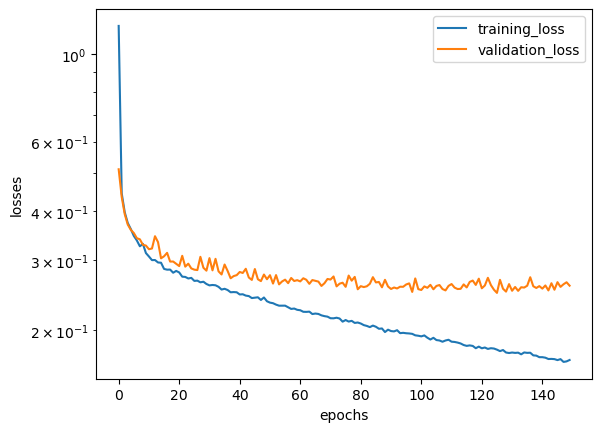

In [144]:
import matplotlib.pyplot as plt 
loss_df=pd.DataFrame(
    {
        "training_loss":train_loss,
        "validation_loss":validation_loss
    }
)
plt.plot(loss_df["training_loss"],label="training_loss")
plt.plot(loss_df["validation_loss"],label="validation_loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.yscale('log') 
plt.legend()

In [145]:
model.load_state_dict(torch.load("best_practice_model"))

<All keys matched successfully>

In [146]:
#evaluate
model.eval()
with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)

    train_mse_loss=criterion(train_pred,y_train_tensor)
    test_mse_loss=criterion(test_pred,y_test_tensor)

    print("MSE train :",train_mse_loss.item())
    print("MSE test :",test_mse_loss.item())

    

MSE train : 0.16513031721115112
MSE test : 0.2482394129037857


In [147]:
from sklearn.metrics import r2_score
print("r^2 score = ",r2_score(y_test,test_pred))

r^2 score =  0.8105634079164092
